In [1]:
import pandas as pd

call_centers = ["A", "B", "C", "D"]
types = ["Daily", "Interval"]

dfs = pd.read_excel("data/Data for Datathon (Revised).xlsx", sheet_name=[
    f"{center} - {type}"
    for center in call_centers
    for type in types
])

In [14]:
df = dfs["A - Daily"][["Date", "CCT"]]
df

,Date,CCT
0,2024-01-01,302.45
1,2024-01-02,349.22
2,2024-01-03,331.07
3,2024-01-04,341.80
4,2024-01-05,334.56
...,...,...
726,2025-12-27,318.87
727,2025-12-28,298.36
728,2025-12-29,334.15
729,2025-12-30,332.86


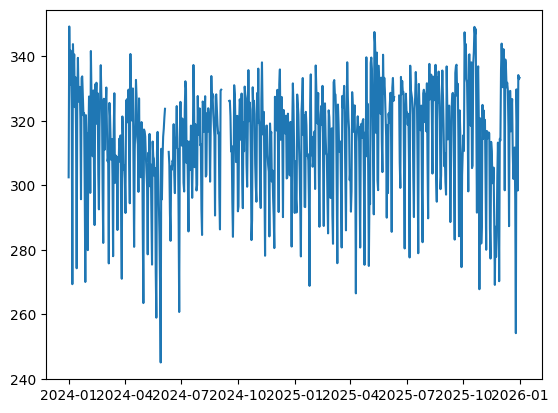

In [15]:
import matplotlib.pyplot as plt
plt.plot(df["Date"], df["CCT"])

In [19]:
from copy import deepcopy as dc

def prepare_df_for_lstm(df, n_steps):
    df = dc(df)
    df['Date'] = pd.to_datetime(df['Date'])
    
    df.set_index('Date', inplace=True)
    
    for i in reversed(range(1, n_steps+1)):
        df[f'CCT(t-{i})'] = df['CCT'].shift(i)
    
    df.dropna(inplace=True)
    
    return df

lookback = 7
shifted_df = prepare_df_for_lstm(df, lookback)
shifted_df

,CCT,CCT(t-7),CCT(t-6),CCT(t-5),CCT(t-4),CCT(t-3),CCT(t-2),CCT(t-1)
Date,,,,,,,,
2024-01-08,343.75,302.45,349.22,331.07,341.80,334.56,323.18,269.32
2024-01-09,334.94,349.22,331.07,341.80,334.56,323.18,269.32,343.75
2024-01-10,340.56,331.07,341.80,334.56,323.18,269.32,343.75,334.94
2024-01-11,324.22,341.80,334.56,323.18,269.32,343.75,334.94,340.56
2024-01-12,333.50,334.56,323.18,269.32,343.75,334.94,340.56,324.22
...,...,...,...,...,...,...,...,...
2025-12-27,318.87,310.08,301.96,309.27,311.69,295.41,254.13,329.72
2025-12-28,298.36,301.96,309.27,311.69,295.41,254.13,329.72,318.87
2025-12-29,334.15,309.27,311.69,295.41,254.13,329.72,318.87,298.36


In [30]:
import torch

device = 'cuda:0' if torch.cuda.is_available else 'cpu'
device

'cuda:0'

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_shifted_df = torch.tensor(scaler.fit_transform(shifted_df.to_numpy()), dtype=torch.bfloat16, device=device)

normalized_shifted_df

RuntimeError: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver.

In [ ]:
X = normalized_shifted_df[:, 1:]
y = normalized_shifted_df[:, 0]

X.shape, y.shape

((679, 7), (679,))

In [29]:
normalized_shifted_df.device

device(type='cpu')

In [23]:
split_index = int(len(X) * .95)
split_index

645

In [27]:
# need to add dimensions for LSTM
X_train = X[:split_index].reshape(-1, lookback, 1)
X_test = X[split_index:].reshape(-1, lookback, 1)

y_train = y[:split_index].reshape(-1, 1)
y_test = y[split_index:].reshape(-1, 1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((645, 7, 1), (34, 7, 1), (645, 1), (34, 1))